## Selección del modelo

### By:
Miguel Angel Toro Ramos

### Date:
2026-08-25

### Description:

Selección manual del mejor modelo de machine learning para predecir `Chance of Admit `. Se reutiliza
el pipeline de preparación de las etapas anteriores, se evalúan siete familias de modelos, se
descartan las que rinden por debajo del promedio, se comparan las restantes con validación cruzada y
pruebas estadísticas, se optimizan los hiperparámetros de las tres mejores y se selecciona un modelo
final que debe superar al modelo base. El pipeline completo se almacena en formato `.joblib`.

## 📚 Import  libraries

In [1]:
# base libraries for data science
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as sk
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RepeatedKFold,
    ShuffleSplit,
    cross_val_score,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42

## 💾 Load data

In [2]:
# resolve the project root by walking up until pyproject.toml is found,
# so the notebook works regardless of the directory Jupyter was launched from
PROJECT_DIR = next(
    p
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / "pyproject.toml").exists()
)
DATA_DIR = PROJECT_DIR / "data"

admisiones_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/admisiones_type_fixed.parquet", engine="pyarrow"
)

In [3]:
# print library version for reproducibility

print("Pandas version: ", pd.__version__)
print("sklearn version: ", sk.__version__)

Pandas version:  3.0.5
sklearn version:  1.9.0


## 👷 Data preparation

Se replican los pasos de limpieza de las etapas anteriores. Repetirlos aquí mantiene el notebook
autocontenido y garantiza que la selección de modelos se realice exactamente sobre los mismos datos
con los que se midió el modelo base: si la preparación difiriera, la comparación contra el baseline
dejaría de ser válida.

In [4]:
modelos_df = admisiones_df.copy()

### Duplicados exactos

In [5]:
duplicate_rows = modelos_df.duplicated().sum()
print("Number of duplicate rows: ", duplicate_rows)

modelos_df = modelos_df.drop_duplicates()
print("Filas tras eliminar duplicados exactos:", len(modelos_df))

Number of duplicate rows:  152
Filas tras eliminar duplicados exactos: 471


### Duplicados ocultos tras valores faltantes

`drop_duplicates()` compara valor a valor y `NaN` nunca es igual a `NaN`, de modo que dos registros
idénticos en los que uno perdió un dato no se detectan como duplicados. Se aplica el criterio de
compatibilidad en el solapamiento observado: dos filas son el mismo registro cuando coinciden en
todas las columnas donde ambas tienen dato.

In [6]:
def marcar_duplicados_compatibles(frame):
    """Flag rows that repeat an earlier record.

    Two rows are treated as the same record when they agree on every column where
    both hold an observed value. Rows differing only in the position of a missing
    value are therefore detected, unlike `DataFrame.duplicated()`, for which NaN is
    never equal to NaN. The first occurrence of each group is kept.
    """
    values = frame.astype({column: "float64" for column in frame.columns}).to_numpy()
    observed = ~np.isnan(values)
    is_duplicate = np.zeros(len(values), dtype=bool)

    for i in range(len(values)):
        if is_duplicate[i]:
            continue
        both = observed[i] & observed[i + 1 :]
        same = np.where(both, values[i] == values[i + 1 :], True).all(axis=1) & both.any(axis=1)
        is_duplicate[np.nonzero(same)[0] + i + 1] = True

    return pd.Series(is_duplicate, index=frame.index)

In [7]:
duplicados_ocultos = marcar_duplicados_compatibles(modelos_df)
print("Duplicados ocultos tras un valor faltante:", int(duplicados_ocultos.sum()))

modelos_df = modelos_df[~duplicados_ocultos]
print("Filas restantes:", len(modelos_df))
print("Valores faltantes tras la deduplicación:", int(modelos_df.isna().sum().sum()))

Duplicados ocultos tras un valor faltante: 71
Filas restantes: 400
Valores faltantes tras la deduplicación: 0


## 👨‍🏭 Feature Engineering

Se reconstruye sin cambios el `ColumnTransformer` de la etapa de ingeniería de atributos:

- **Numéricas continuas y ordinales**: imputación por mediana y estandarización.
- **Binaria**: `Research` se codifica con `OrdinalEncoder` a valores 0/1 y se imputa por moda.

`OrdinalEncoder` recibe `handle_unknown="use_encoded_value"` con `unknown_value=np.nan`: sin esa
opción, al re-ajustarse sobre un pliegue donde `Research` no presenta faltantes, un `NaN` en la
partición de validación se trataría como categoría desconocida y la transformación fallaría.
`set_output(transform="pandas")` conserva los nombres de columna a través del pipeline.

Los imputadores se mantienen aunque el conjunto deduplicado ya no tenga faltantes: son parte del
contrato de preparación y deben seguir operativos frente a datos nuevos.

In [8]:
cols_numeric = ["GRE Score", "TOEFL Score", "University Rating", "SOP", "LOR ", "CGPA"]
cols_binary = ["Research"]

In [9]:
def construir_preprocessor():
    """Build a fresh preprocessing transformer.

    A new instance is returned on every call so that each model gets its own
    unfitted copy and no state leaks between candidates.
    """
    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    binary_pipe = Pipeline(
        steps=[
            (
                "encoder",
                OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan),
            ),
            ("imputer", SimpleImputer(strategy="most_frequent")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipe, cols_numeric),
            ("binary", binary_pipe, cols_binary),
        ]
    )
    preprocessor.set_output(transform="pandas")
    return preprocessor


construir_preprocessor()

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('binary', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

## ✂️ Train / Test split

La partición replica exactamente la de las etapas anteriores: `test_size=0.2`,
`random_state=42` y estratificación por quintiles del objetivo construidos con `pd.qcut`. Mantener
el mismo criterio es lo que permite comparar estos modelos contra el modelo base.

In [10]:
X_features = modelos_df.drop(columns=["Chance of Admit "])
Y_target = modelos_df["Chance of Admit "]

# 80% train, 20% test
y_bins = pd.qcut(Y_target, q=5, labels=False, duplicates="drop")
x_train, x_test, y_train, y_test = train_test_split(
    X_features, Y_target, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bins
)

print("train:", x_train.shape, "| test:", x_test.shape)

train: (320, 7) | test: (80, 7)


Verificación de que la deduplicación eliminó la fuga entre particiones: ninguna fila de prueba debe
existir también en entrenamiento.

In [11]:
preprocessor_check = construir_preprocessor().fit(x_train)
train_keys = set(map(tuple, preprocessor_check.transform(x_train).round(10).to_numpy()))
overlap = np.array(
    [tuple(row) in train_keys for row in preprocessor_check.transform(x_test).round(10).to_numpy()]
)
print(f"Filas de test con gemela exacta en train: {overlap.sum()} de {len(overlap)}")

Filas de test con gemela exacta en train: 0 de 80


## 🤖 Models

El objetivo es continuo, de modo que el problema es de **regresión**. Se seleccionan siete familias
con mecanismos de aprendizaje distintos, no siete variantes del mismo mecanismo:

| Familia | Modelo | Mecanismo |
|---|---|---|
| Lineal regularizado L2 | `Ridge` | penaliza la magnitud de los coeficientes |
| Lineal regularizado L1 | `Lasso` | anula coeficientes, selecciona atributos |
| Lineal mixto L1+L2 | `ElasticNet` | combina ambas penalizaciones |
| Árbol individual | `DecisionTreeRegressor` | particiones sucesivas del espacio |
| Ensamble por bagging | `RandomForestRegressor` | promedio de árboles decorrelacionados |
| Ensamble por boosting | `HistGradientBoostingRegressor` | árboles secuenciales sobre el residuo |
| Basado en distancias | `KNeighborsRegressor` | promedio de los vecinos más próximos |
| Kernel | `SVR` | regresión de margen en espacio transformado |

Se incluye además `DummyRegressor` como piso: predice siempre la media del entrenamiento y sirve
para confirmar que cualquier candidato aporta algo.

**La métrica principal es el MAE**, definida en la etapa del modelo base por ser la única
interpretable en las unidades del objetivo: un MAE de 0.05 significa equivocarse en 5 puntos de
probabilidad de admisión. RMSE y R² se reportan como métricas de apoyo.

In [12]:
MODELOS = {
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=5000),
    "ElasticNet": ElasticNet(random_state=RANDOM_STATE, max_iter=5000),
    "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "KNeighbors": KNeighborsRegressor(),
    "SVR": SVR(),
    "DummyMean": DummyRegressor(strategy="mean"),
}

print(f"{len(MODELOS)} modelos candidatos")

9 modelos candidatos


## 🔍 Basic Model Selection

Primera criba con hiperparámetros por defecto. El objetivo no es medir con precisión sino descartar
rápidamente lo que claramente no funciona antes de invertir cómputo en validación cruzada repetida y
optimización.

### Simple Train and Evaluate

Cada modelo se encadena con su propio `preprocessor` en un `Pipeline`, se ajusta sobre entrenamiento
y se evalúa sobre prueba. Encadenarlos es indispensable: garantiza que la imputación y el escalado se
aprendan solo del conjunto de entrenamiento.

In [13]:
resultados_simples = []
for nombre, modelo in MODELOS.items():
    pipe = Pipeline(steps=[("preprocessor", construir_preprocessor()), ("model", modelo)])
    pipe.fit(x_train, y_train)
    prediccion = pipe.predict(x_test)
    resultados_simples.append(
        {
            "modelo": nombre,
            "MAE": mean_absolute_error(y_test, prediccion),
            "RMSE": root_mean_squared_error(y_test, prediccion),
            "R2": r2_score(y_test, prediccion),
        }
    )

simples_df = pd.DataFrame(resultados_simples).set_index("modelo").sort_values("MAE")
simples_df.round(4)

,MAE,RMSE,R2
modelo,,,
Ridge,0.0468,0.0721,0.7502
KNeighbors,0.0470,0.0738,0.7380
RandomForest,0.0486,0.0712,0.7562
HistGradientBoosting,0.0501,0.0729,0.7443
DecisionTree,0.0636,0.0914,0.5987
SVR,0.0672,0.0793,0.6975
ElasticNet,0.1174,0.1442,-0.0000
Lasso,0.1174,0.1442,-0.0000
DummyMean,0.1174,0.1442,-0.0000


### Model Comparison

Comparación visual de la primera evaluación. Se marca el MAE del modelo base para situar a los
candidatos respecto de la referencia que deben superar.

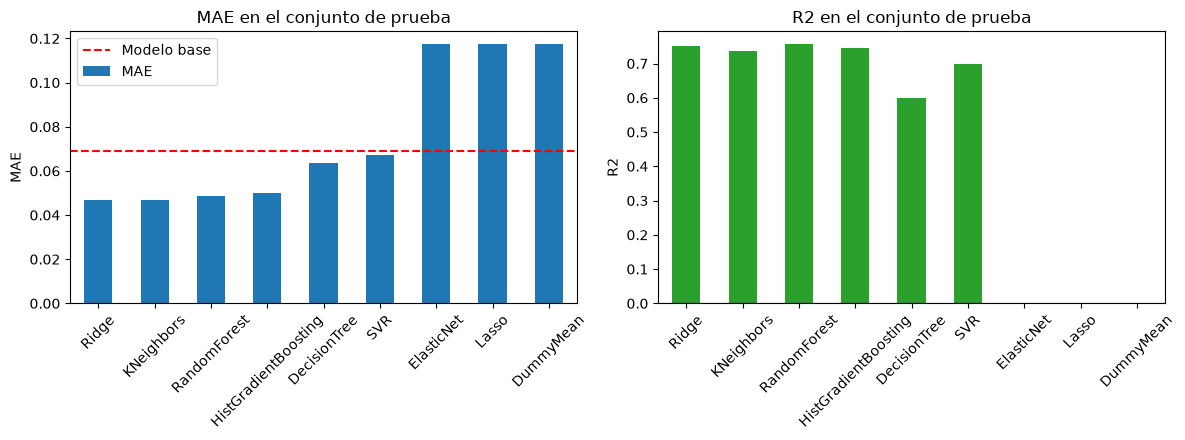

In [14]:
MAE_BASELINE_TEST = 0.0690

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4.5))

simples_df["MAE"].plot(kind="bar", ax=axes[0], rot=45, color="tab:blue")
axes[0].axhline(MAE_BASELINE_TEST, color="red", linestyle="--", label="Modelo base")
axes[0].set_title("MAE en el conjunto de prueba")
axes[0].set_ylabel("MAE")
axes[0].set_xlabel("")
axes[0].legend(loc="best")

simples_df["R2"].plot(kind="bar", ax=axes[1], rot=45, color="tab:green")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("R2 en el conjunto de prueba")
axes[1].set_ylabel("R2")
axes[1].set_xlabel("")

fig.tight_layout()
plt.show()

### First Selection of Models

Se descartan los modelos cuyo MAE supera el promedio de los candidatos. El `DummyRegressor` queda
fuera del cálculo del promedio: es una referencia, no un candidato, e incluirlo desplazaría el
umbral hacia arriba y dejaría pasar modelos peores.

In [15]:
candidatos = simples_df.drop(index="DummyMean")
umbral_mae = candidatos["MAE"].mean()

seleccionados = candidatos[candidatos["MAE"] <= umbral_mae].index.tolist()
descartados = candidatos[candidatos["MAE"] > umbral_mae].index.tolist()

print(f"MAE promedio de los candidatos: {umbral_mae:.4f}")
print("Seleccionados:", seleccionados)
print("Descartados  :", descartados)

MAE promedio de los candidatos: 0.0698
Seleccionados: ['Ridge', 'KNeighbors', 'RandomForest', 'HistGradientBoosting', 'DecisionTree', 'SVR']
Descartados  : ['ElasticNet', 'Lasso']


## 🔁 Cross validation model Selection

Los modelos supervivientes se evalúan con validación cruzada de diez particiones sobre el conjunto de
entrenamiento. El `preprocessor` va dentro del `Pipeline`, de modo que cada partición re-ajusta
también la imputación y el escalado con sus propios datos; ajustarlo una sola vez fuera del bucle
filtraría información hacia los pliegues de validación.

In [16]:
kfold = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

resultados_cv = []
for nombre in seleccionados:
    pipe = Pipeline(steps=[("preprocessor", construir_preprocessor()), ("model", MODELOS[nombre])])
    marcadores = cross_validate(
        pipe,
        x_train,
        y_train,
        cv=kfold,
        n_jobs=-1,
        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"],
    )
    resultados_cv.append(
        {
            "modelo": nombre,
            "MAE media": -marcadores["test_neg_mean_absolute_error"].mean(),
            "MAE desv": marcadores["test_neg_mean_absolute_error"].std(ddof=1),
            "RMSE media": -marcadores["test_neg_root_mean_squared_error"].mean(),
            "R2 media": marcadores["test_r2"].mean(),
            "R2 desv": marcadores["test_r2"].std(ddof=1),
        }
    )

cv_df = pd.DataFrame(resultados_cv).set_index("modelo").sort_values("MAE media")
cv_df.round(4)

,MAE media,MAE desv,RMSE media,R2 media,R2 desv
modelo,,,,,
Ridge,0.0458,0.0069,0.0623,0.7898,0.0619
KNeighbors,0.0494,0.0060,0.0673,0.7593,0.0486
RandomForest,0.0504,0.0072,0.0696,0.7422,0.0529
HistGradientBoosting,0.0528,0.0066,0.0712,0.7279,0.0627
SVR,0.0631,0.0069,0.0784,0.6706,0.0765
DecisionTree,0.0734,0.0103,0.0990,0.4767,0.1103


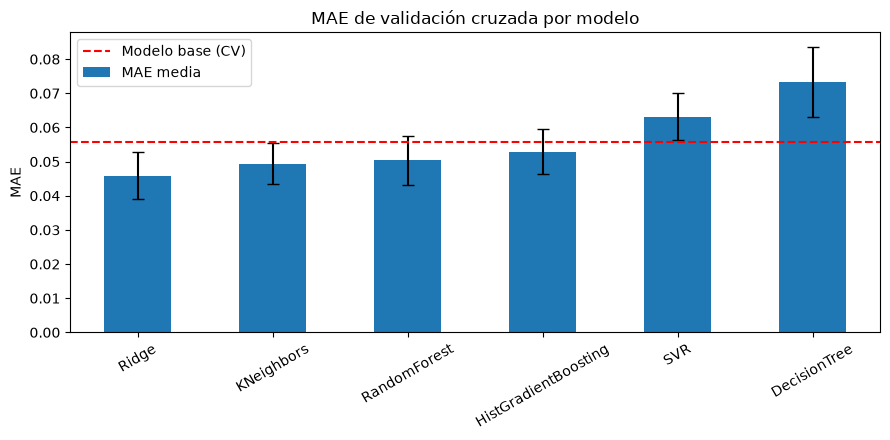

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
cv_df["MAE media"].plot(kind="bar", yerr=cv_df["MAE desv"], ax=ax, capsize=4, rot=30)
ax.axhline(0.0558, color="red", linestyle="--", label="Modelo base (CV)")
ax.set_title("MAE de validación cruzada por modelo")
ax.set_ylabel("MAE")
ax.set_xlabel("")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

## 📐 Statistical Model Comparison

Comparar medias no basta. Con diez particiones y desviaciones del orden de 0.007 en MAE, dos modelos
separados por 0.004 pueden ser indistinguibles. Hace falta una prueba estadística, y se aplica en el
orden habitual de dos pasos:

1. **Prueba ómnibus** — ¿existe alguna diferencia entre los modelos? Se usa un ANOVA de un factor
   (`f_oneway`).
2. **Prueba post-hoc por pares** — ¿entre cuáles está esa diferencia? Sin este segundo paso no es
   posible seleccionar un modelo: la prueba ómnibus indica que *alguno* difiere, no cuál.

Para el segundo paso hay una trampa que conviene tener presente: **un t-test pareado ingenuo sobre
los resultados por pliegue viola el supuesto de independencia**, porque los conjuntos de
entrenamiento de los distintos pliegues se solapan fuertemente —con diez particiones sobre 320 filas,
dos pliegues cualesquiera comparten el 89% de sus datos—. El resultado son p-valores artificialmente
pequeños. La corrección de Nadeau y Bengio ajusta la varianza teniendo en cuenta ese solapamiento:

$$\sigma^2_{corregida} = \sigma^2 \left( \frac{1}{n} + \frac{n_{test}}{n_{train}} \right)$$

Se usa validación cruzada repetida —diez particiones por tres repeticiones, 30 mediciones— para
estabilizar la estimación.

In [18]:
NIVEL_SIGNIFICANCIA = 0.05


def t_test_corregido(diferencias, n_train, n_test):
    """Paired t-test with the Nadeau-Bengio variance correction.

    A naive paired t-test over cross-validation folds assumes the measurements are
    independent, which they are not: the training sets overlap heavily. The
    correction inflates the variance to account for that overlap, producing
    p-values that are not artificially optimistic.
    """
    n = len(diferencias)
    varianza_corregida = diferencias.var(ddof=1) * (1 / n + n_test / n_train)
    if varianza_corregida <= 0:
        return np.nan, np.nan
    t_stat = diferencias.mean() / np.sqrt(varianza_corregida)
    p_valor = 2 * stats.t.sf(np.abs(t_stat), df=n - 1)
    return t_stat, p_valor

In [19]:
FINALISTAS = cv_df.index[:3].tolist()
print("Finalistas:", FINALISTAS)

repeticiones = RepeatedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)
marcadores_repetidos = {}
for nombre in FINALISTAS:
    pipe = Pipeline(steps=[("preprocessor", construir_preprocessor()), ("model", MODELOS[nombre])])
    marcadores_repetidos[nombre] = cross_val_score(
        pipe,
        x_train,
        y_train,
        cv=repeticiones,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    puntajes = marcadores_repetidos[nombre]
    print(f"  {nombre:22s} MAE={-puntajes.mean():.4f} +/- {puntajes.std(ddof=1):.4f}")

Finalistas: ['Ridge', 'KNeighbors', 'RandomForest']


  Ridge                  MAE=0.0457 +/- 0.0067


  KNeighbors             MAE=0.0495 +/- 0.0066


  RandomForest           MAE=0.0503 +/- 0.0073


### Paso 1 — Prueba ómnibus (ANOVA)

Contrasta la hipótesis nula de que los tres modelos tienen el mismo desempeño medio.

In [20]:
model1 = -marcadores_repetidos[FINALISTAS[0]]
model2 = -marcadores_repetidos[FINALISTAS[1]]
model3 = -marcadores_repetidos[FINALISTAS[2]]

statistic, p_value = stats.f_oneway(model1, model2, model3)

print(f"Statistic: {statistic}")
print(f"p_value: {p_value}")

if p_value < NIVEL_SIGNIFICANCIA:
    print(
        "There is a statistically significant difference "
        "in the cross-validation results of the models."
    )
else:
    print(
        "There is no statistically significant difference "
        "in the cross-validation results of the models."
    )

Statistic: 3.790873850559549
p_value: 0.02639176453721998
There is a statistically significant difference in the cross-validation results of the models.


La prueba ómnibus indica si existe alguna diferencia, pero no cuál modelo elegir. Conviene además
tener presentes sus dos limitaciones en este contexto, porque afectan al resultado en direcciones
opuestas:

- **Ignora el pareo entre modelos.** Los tres se evaluaron sobre las mismas particiones, de modo que
  las muestras no son independientes. La variabilidad propia de cada pliegue —que afecta por igual a
  los tres modelos— no se cancela y termina en el denominador del estadístico F, lo que **resta
  potencia** a la prueba.
- **Ignora el solapamiento entre pliegues**, lo que actúa en sentido contrario y **añade potencia
  falsa**, igual que en el t-test sin corregir.

Por eso el paso siguiente usa una prueba pareada y corregida: aprovecha que las mediciones están
apareadas y a la vez descuenta el solapamiento.

### Paso 2 — Prueba post-hoc por pares (t-test corregido)

In [21]:
n_test_fold = len(x_train) / 10
n_train_fold = len(x_train) - n_test_fold

comparaciones = []
for i, primero in enumerate(FINALISTAS):
    for segundo in FINALISTAS[i + 1 :]:
        diferencias = marcadores_repetidos[primero] - marcadores_repetidos[segundo]
        t_stat, p_valor = t_test_corregido(diferencias, n_train_fold, n_test_fold)
        _, p_ingenuo = stats.ttest_rel(marcadores_repetidos[primero], marcadores_repetidos[segundo])
        comparaciones.append(
            {
                "comparación": f"{primero} vs {segundo}",
                "dif. MAE": -diferencias.mean(),
                "t corregido": t_stat,
                "p corregido": p_valor,
                "p ingenuo": p_ingenuo,
                "significativo": "sí" if p_valor < NIVEL_SIGNIFICANCIA else "no",
            }
        )

comparaciones_df = pd.DataFrame(comparaciones).set_index("comparación")
comparaciones_df.round(4)

,dif. MAE,t corregido,p corregido,p ingenuo,significativo
comparación,,,,,
Ridge vs KNeighbors,-0.0038,1.8316,0.0773,0.0007,no
Ridge vs RandomForest,-0.0046,2.5763,0.0153,0.0000,sí
KNeighbors vs RandomForest,-0.0008,0.3575,0.7233,0.4628,no


La columna `p ingenuo` está solo para mostrar la magnitud del problema: el t-test sin corregir
declara diferencias altamente significativas donde la prueba corregida no encuentra evidencia
suficiente. Es la diferencia entre concluir "este modelo es mejor" y "no puedo distinguirlos".

## 🎛️ Hyperparameter tunning

Los tres finalistas se optimizan con `GridSearchCV` sobre el `Pipeline` completo, usando la misma
validación cruzada de diez particiones y el MAE como criterio. Optimizar sobre el pipeline y no
sobre el modelo aislado es lo que impide que el preprocesamiento se ajuste con datos de validación.

In [22]:
REJILLAS = {
    "Ridge": {"model__alpha": np.logspace(-3, 3, 13)},
    "Lasso": {"model__alpha": np.logspace(-4, 1, 12)},
    "ElasticNet": {
        "model__alpha": np.logspace(-4, 1, 10),
        "model__l1_ratio": [0.1, 0.5, 0.9],
    },
    "KNeighbors": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
    "RandomForest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 4, 6, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": [1.0, 0.6],
    },
    "HistGradientBoosting": {
        "model__learning_rate": [0.03, 0.1],
        "model__max_depth": [None, 3, 6],
        "model__min_samples_leaf": [5, 10, 20],
    },
    "DecisionTree": {
        "model__max_depth": [3, 4, 6, 10, None],
        "model__min_samples_leaf": [1, 2, 5, 10],
    },
    "SVR": {
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", 0.01, 0.1],
        "model__epsilon": [0.01, 0.05, 0.1],
    },
}

optimizados = {}
resumen_tuning = []
for nombre in FINALISTAS:
    busqueda = GridSearchCV(
        Pipeline(
            steps=[
                ("preprocessor", construir_preprocessor()),
                ("model", MODELOS[nombre]),
            ]
        ),
        REJILLAS[nombre],
        cv=kfold,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    busqueda.fit(x_train, y_train)
    optimizados[nombre] = busqueda.best_estimator_
    resumen_tuning.append(
        {
            "modelo": nombre,
            "MAE CV optimizado": -busqueda.best_score_,
            "hiperparámetros": {
                clave.replace("model__", ""): valor
                for clave, valor in busqueda.best_params_.items()
            },
        }
    )

tuning_df = pd.DataFrame(resumen_tuning).set_index("modelo")
tuning_df

,MAE CV optimizado,hiperparámetros
modelo,,
Ridge,0.045656,{'alpha': 10.0}
KNeighbors,0.047791,"{'n_neighbors': 21, 'p': 2, 'weights': 'distan..."
RandomForest,0.047459,"{'max_depth': 4, 'max_features': 0.6, 'min_sam..."


## ⚖️ Model comparison

Los tres modelos optimizados se vuelven a comparar con el mismo protocolo repetido y la misma prueba
corregida. Se contrasta además cada modelo optimizado contra su versión por defecto, para determinar
si la optimización aportó algo medible.

In [23]:
for nombre in FINALISTAS:
    marcadores_repetidos[f"{nombre} (opt)"] = cross_val_score(
        optimizados[nombre],
        x_train,
        y_train,
        cv=repeticiones,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )

Se repite primero la prueba ómnibus sobre los tres modelos ya optimizados.

In [24]:
statistic_opt, p_value_opt = stats.f_oneway(
    *[-marcadores_repetidos[f"{nombre} (opt)"] for nombre in FINALISTAS]
)

print(f"Statistic: {statistic_opt}")
print(f"p_value: {p_value_opt}")

if p_value_opt < NIVEL_SIGNIFICANCIA:
    print(
        "There is a statistically significant difference "
        "in the cross-validation results of the models."
    )
else:
    print(
        "There is no statistically significant difference "
        "in the cross-validation results of the models."
    )

Statistic: 0.9008109945764108
p_value: 0.4099948576478597
There is no statistically significant difference in the cross-validation results of the models.


In [25]:
comparaciones_finales = []
for i, primero in enumerate(FINALISTAS):
    for segundo in FINALISTAS[i + 1 :]:
        diferencias = (
            marcadores_repetidos[f"{primero} (opt)"] - marcadores_repetidos[f"{segundo} (opt)"]
        )
        t_stat, p_valor = t_test_corregido(diferencias, n_train_fold, n_test_fold)
        comparaciones_finales.append(
            {
                "comparación": f"{primero} vs {segundo} (optimizados)",
                "dif. MAE": -diferencias.mean(),
                "t corregido": t_stat,
                "p corregido": p_valor,
                "significativo": "sí" if p_valor < NIVEL_SIGNIFICANCIA else "no",
            }
        )

for nombre in FINALISTAS:
    diferencias = marcadores_repetidos[f"{nombre} (opt)"] - marcadores_repetidos[nombre]
    t_stat, p_valor = t_test_corregido(diferencias, n_train_fold, n_test_fold)
    comparaciones_finales.append(
        {
            "comparación": f"{nombre}: optimizado vs defecto",
            "dif. MAE": -diferencias.mean(),
            "t corregido": t_stat,
            "p corregido": p_valor,
            "significativo": "sí" if p_valor < NIVEL_SIGNIFICANCIA else "no",
        }
    )

finales_df = pd.DataFrame(comparaciones_finales).set_index("comparación")
finales_df.round(4)

,dif. MAE,t corregido,p corregido,significativo
comparación,,,,
Ridge vs KNeighbors (optimizados),-0.0023,1.4764,0.1506,no
Ridge vs RandomForest (optimizados),-0.0020,1.6210,0.1158,no
KNeighbors vs RandomForest (optimizados),0.0003,-0.1759,0.8616,no
Ridge: optimizado vs defecto,-0.0002,0.7826,0.4402,no
KNeighbors: optimizado vs defecto,-0.0017,1.0676,0.2945,no
RandomForest: optimizado vs defecto,-0.0027,2.4592,0.0201,sí


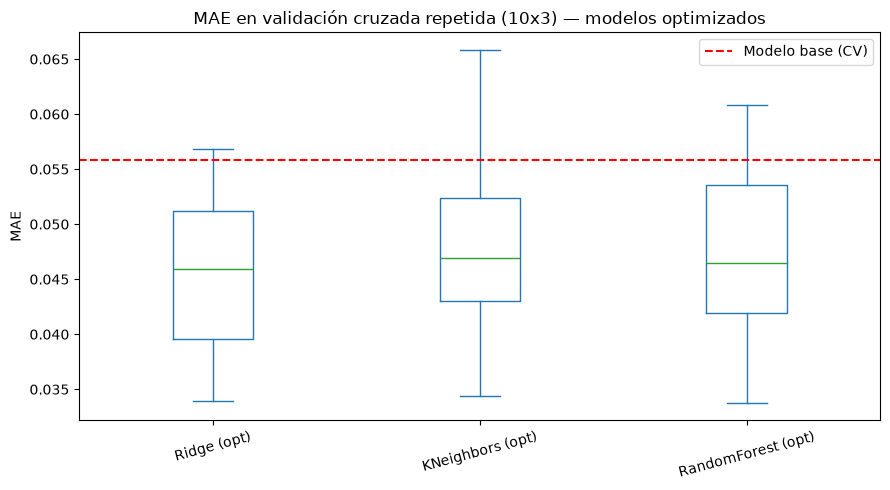

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
datos_caja = pd.DataFrame(
    {f"{nombre} (opt)": -marcadores_repetidos[f"{nombre} (opt)"] for nombre in FINALISTAS}
)
datos_caja.plot.box(ax=ax, rot=15)
ax.axhline(0.0558, color="red", linestyle="--", label="Modelo base (CV)")
ax.set_title("MAE en validación cruzada repetida (10x3) — modelos optimizados")
ax.set_ylabel("MAE")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

### Modelo seleccionado

Cuando la prueba estadística no distingue entre varios modelos, la media más baja deja de ser un
criterio suficiente: elegir por una diferencia que no es significativa es elegir por ruido. En ese
caso la decisión se toma con criterios secundarios —simplicidad, interpretabilidad y coste de
ajuste— que sí son observables y estables.

In [27]:
MODELO_ELEGIDO = tuning_df["MAE CV optimizado"].idxmin()
modelo_final = optimizados[MODELO_ELEGIDO]

print("Modelo seleccionado:", MODELO_ELEGIDO)
print("Hiperparámetros:", tuning_df.loc[MODELO_ELEGIDO, "hiperparámetros"])
modelo_final

Modelo seleccionado: Ridge
Hiperparámetros: {'alpha': np.float64(10.0)}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['GRE Score','TOEFL Score','University Rating',...,'LOR ','CGPA', 'Research']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('binary', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

## 🏁 Entrenamiento final y evaluación sobre test

El modelo seleccionado se ajusta con todo el conjunto de entrenamiento y se evalúa una única vez
sobre el conjunto de prueba, que hasta este punto no intervino en ninguna decisión.

In [28]:
modelo_final.fit(x_train, y_train)

prediccion_train = modelo_final.predict(x_train)
prediccion_test = modelo_final.predict(x_test)

evaluacion = pd.DataFrame(
    [
        {
            "conjunto": "train",
            "MAE": mean_absolute_error(y_train, prediccion_train),
            "RMSE": root_mean_squared_error(y_train, prediccion_train),
            "R2": r2_score(y_train, prediccion_train),
        },
        {
            "conjunto": "test",
            "MAE": mean_absolute_error(y_test, prediccion_test),
            "RMSE": root_mean_squared_error(y_test, prediccion_test),
            "R2": r2_score(y_test, prediccion_test),
        },
    ]
).set_index("conjunto")

evaluacion.round(4)

,MAE,RMSE,R2
conjunto,,,
train,0.0443,0.0609,0.8158
test,0.0467,0.0722,0.7496


### Comparación contra el modelo base

El requerimiento exige que el modelo seleccionado supere al modelo base. Las cifras de referencia
provienen del notebook anterior.

In [29]:
MAE_BASELINE_CV = 0.0558
R2_BASELINE_CV = 0.7235
R2_BASELINE_TEST = 0.6057

cv_mae_final = -cross_val_score(
    modelo_final,
    x_train,
    y_train,
    cv=kfold,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
cv_r2_final = cross_val_score(modelo_final, x_train, y_train, cv=kfold, scoring="r2", n_jobs=-1)

comparativa = pd.DataFrame(
    {
        "Modelo base": [
            MAE_BASELINE_CV,
            R2_BASELINE_CV,
            MAE_BASELINE_TEST,
            R2_BASELINE_TEST,
        ],
        MODELO_ELEGIDO: [
            cv_mae_final.mean(),
            cv_r2_final.mean(),
            mean_absolute_error(y_test, prediccion_test),
            r2_score(y_test, prediccion_test),
        ],
    },
    index=["MAE (CV)", "R2 (CV)", "MAE (test)", "R2 (test)"],
)
comparativa["mejora"] = [
    f"{(comparativa.iloc[0, 0] - comparativa.iloc[0, 1]) / comparativa.iloc[0, 0]:+.1%}",
    f"{(comparativa.iloc[1, 1] - comparativa.iloc[1, 0]) / comparativa.iloc[1, 0]:+.1%}",
    f"{(comparativa.iloc[2, 0] - comparativa.iloc[2, 1]) / comparativa.iloc[2, 0]:+.1%}",
    f"{(comparativa.iloc[3, 1] - comparativa.iloc[3, 0]) / comparativa.iloc[3, 0]:+.1%}",
]
comparativa.round(4)

,Modelo base,Ridge,mejora
MAE (CV),0.0558,0.0457,+18.2%
R2 (CV),0.7235,0.7903,+9.2%
MAE (test),0.0690,0.0467,+32.3%
R2 (test),0.6057,0.7496,+23.8%


### Diagnóstico de sobreajuste y subajuste

Se contrastan tres cifras: el desempeño sobre entrenamiento, el de validación cruzada y el de prueba.
Una brecha amplia entre entrenamiento y validación indica sobreajuste; un desempeño bajo en las tres
indica subajuste.

In [30]:
brecha_r2 = r2_score(y_train, prediccion_train) - r2_score(y_test, prediccion_test)

print(f"R2 train : {r2_score(y_train, prediccion_train):.4f}")
print(f"R2 CV    : {cv_r2_final.mean():.4f} +/- {cv_r2_final.std(ddof=1):.4f}")
print(f"R2 test  : {r2_score(y_test, prediccion_test):.4f}")
print(f"brecha train - test: {brecha_r2:+.4f}")

fuera_de_rango = int(((prediccion_test < 0) | (prediccion_test > 1)).sum())
print(f"\nPredicciones fuera del rango [0, 1]: {fuera_de_rango}")
print(
    f"Rango de las predicciones de test: [{prediccion_test.min():.4f}, {prediccion_test.max():.4f}]"
)

R2 train : 0.8158
R2 CV    : 0.7903 +/- 0.0635
R2 test  : 0.7496
brecha train - test: +0.0662

Predicciones fuera del rango [0, 1]: 0
Rango de las predicciones de test: [0.4704, 0.9898]


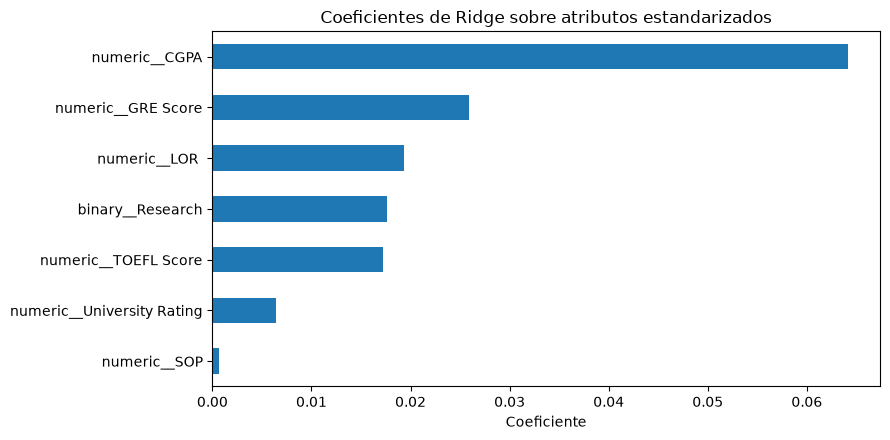

,coeficiente
numeric__CGPA,0.0642
numeric__GRE Score,0.0259
numeric__LOR,0.0194
binary__Research,0.0176
numeric__TOEFL Score,0.0172
numeric__University Rating,0.0064
numeric__SOP,0.0007


In [31]:
coeficientes = pd.DataFrame(
    {"coeficiente": modelo_final.named_steps["model"].coef_},
    index=modelo_final.named_steps["preprocessor"].get_feature_names_out(),
).sort_values("coeficiente", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
coeficientes["coeficiente"].plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title(f"Coeficientes de {MODELO_ELEGIDO} sobre atributos estandarizados")
ax.set_xlabel("Coeficiente")
fig.tight_layout()
plt.show()

coeficientes.round(4)

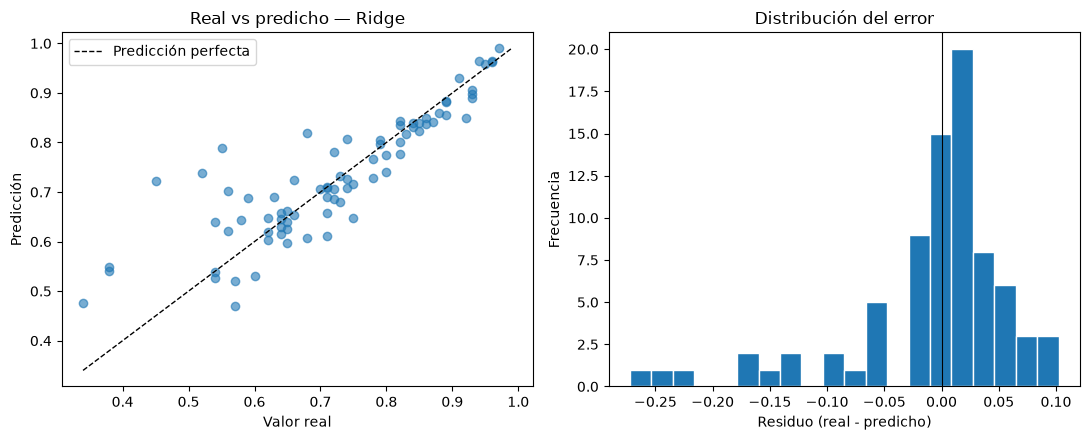

Residuo medio: -0.0098
Residuo absoluto máximo: 0.2722


In [32]:
residuos = y_test.to_numpy() - prediccion_test

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4.5))

axes[0].scatter(y_test, prediccion_test, alpha=0.6)
limites = [
    min(y_test.min(), prediccion_test.min()),
    max(y_test.max(), prediccion_test.max()),
]
axes[0].plot(limites, limites, "--", color="black", linewidth=1, label="Predicción perfecta")
axes[0].set_xlabel("Valor real")
axes[0].set_ylabel("Predicción")
axes[0].set_title(f"Real vs predicho — {MODELO_ELEGIDO}")
axes[0].legend(loc="best")

axes[1].hist(residuos, bins=20, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Residuo (real - predicho)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución del error")

fig.tight_layout()
plt.show()

print(f"Residuo medio: {residuos.mean():+.4f}")
print(f"Residuo absoluto máximo: {np.abs(residuos).max():.4f}")

## 📈 Learning curve

La curva de aprendizaje muestra cómo evolucionan el desempeño de entrenamiento y el de validación al
crecer el número de observaciones. Si ambas convergen en un valor bajo, el modelo está limitado por
su capacidad; si quedan separadas, está memorizando.

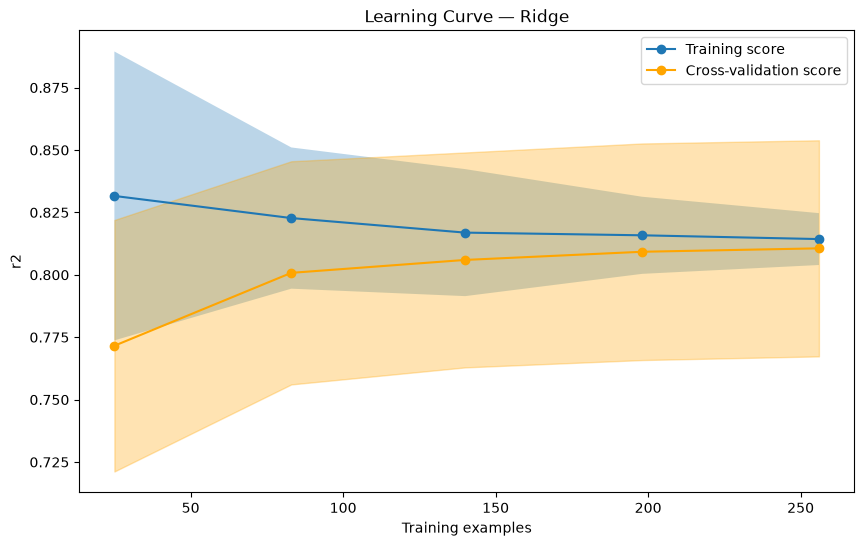

Training Sizes: [ 25  83 140 198 256]
Training Scores Mean: [0.8316 0.8227 0.8169 0.8158 0.8143]
Test Scores Mean:     [0.7716 0.8008 0.806  0.8092 0.8106]
Test Scores Std:      [0.0504 0.0447 0.0431 0.0434 0.0433]


In [33]:
parametros_curva = {
    "X": x_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    "n_jobs": -1,
    "return_times": True,
}
metrica_curva = "r2"

train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    modelo_final, **parametros_curva, scoring=metrica_curva
)

train_mean, train_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
test_mean, test_std = np.mean(test_scores, axis=1), np.std(test_scores, axis=1)
fit_times_mean, fit_times_std = np.mean(fit_times, axis=1), np.std(fit_times, axis=1)
score_times_mean, score_times_std = (
    np.mean(score_times, axis=1),
    np.std(score_times, axis=1),
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, "o-", label="Training score")
ax.plot(train_sizes, test_mean, "o-", color="orange", label="Cross-validation score")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.3)
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.3, color="orange")
ax.set_title(f"Learning Curve — {MODELO_ELEGIDO}")
ax.set_xlabel("Training examples")
ax.set_ylabel(metrica_curva)
ax.legend(loc="best")
plt.show()

print("Training Sizes:", train_sizes)
print("Training Scores Mean:", np.round(train_mean, 4))
print("Test Scores Mean:    ", np.round(test_mean, 4))
print("Test Scores Std:     ", np.round(test_std, 4))

### Escalabilidad

Tiempos de ajuste y de predicción en función del tamaño del conjunto de entrenamiento.

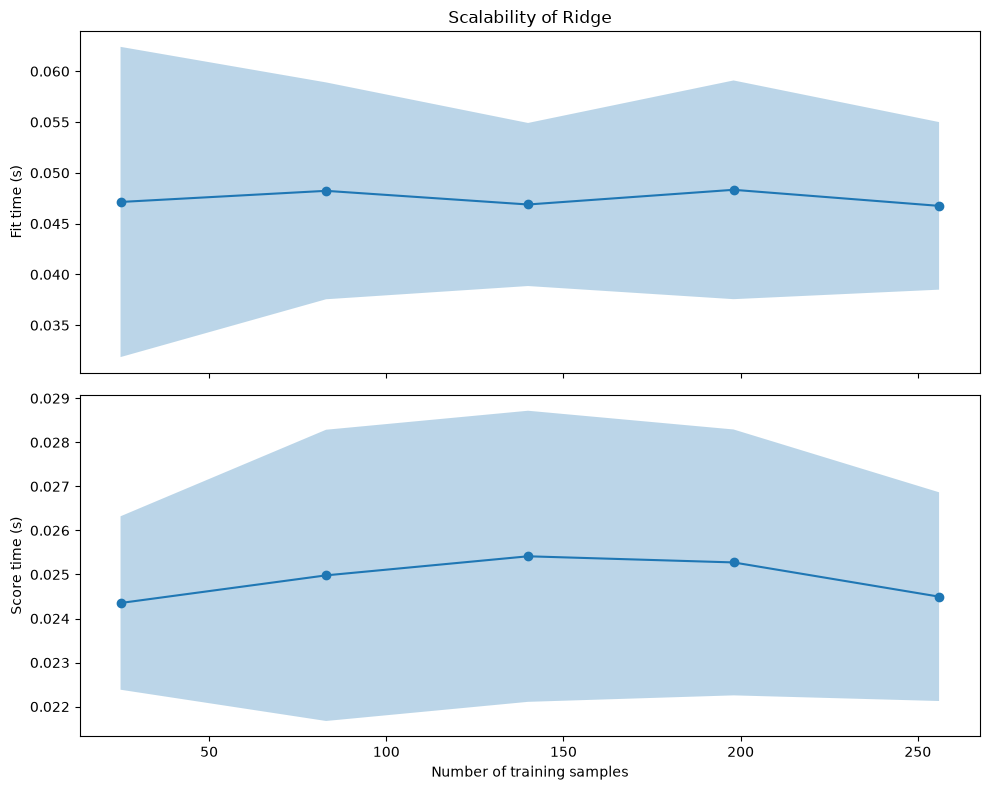

Fit Times Mean:   [0.04713 0.04823 0.04688 0.04833 0.04675]
Score Times Mean: [0.02435 0.02498 0.02541 0.02527 0.0245 ]


In [34]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

ax[0].plot(train_sizes, fit_times_mean, "o-")
ax[0].fill_between(
    train_sizes,
    fit_times_mean - fit_times_std,
    fit_times_mean + fit_times_std,
    alpha=0.3,
)
ax[0].set_ylabel("Fit time (s)")
ax[0].set_title(f"Scalability of {MODELO_ELEGIDO}")

ax[1].plot(train_sizes, score_times_mean, "o-")
ax[1].fill_between(
    train_sizes,
    score_times_mean - score_times_std,
    score_times_mean + score_times_std,
    alpha=0.3,
)
ax[1].set_ylabel("Score time (s)")
ax[1].set_xlabel("Number of training samples")

fig.tight_layout()
plt.show()

print("Fit Times Mean:  ", np.round(fit_times_mean, 5))
print("Score Times Mean:", np.round(score_times_mean, 5))

## 💾 Save the model

Se almacena el `Pipeline` completo —preprocesamiento más modelo— y no solo el estimador. Guardar el
modelo aislado obligaría a reproducir manualmente la imputación, la codificación y el escalado en
cada predicción, con el riesgo de aplicarlos de forma distinta a como se aprendieron.

In [35]:
MODELS_DIR = PROJECT_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)
RUTA_MODELO = MODELS_DIR / "modelo-seleccion-admisiones.joblib"

joblib.dump(modelo_final, RUTA_MODELO)
print("Modelo almacenado en:", RUTA_MODELO)
print("Tamaño:", f"{RUTA_MODELO.stat().st_size / 1024:.1f} KB")

Modelo almacenado en: /home/dell/Admisiones-predict-project/models/modelo-seleccion-admisiones.joblib
Tamaño: 4.8 KB


Verificación de que el artefacto almacenado reproduce exactamente las predicciones del modelo en
memoria. Un pipeline que se guarda pero no se comprueba es una fuente silenciosa de errores en
producción.

In [36]:
modelo_recargado = joblib.load(RUTA_MODELO)
prediccion_recargada = modelo_recargado.predict(x_test)

print("Predicciones idénticas:", np.allclose(prediccion_test, prediccion_recargada))
print(
    "MAE del modelo recargado:",
    round(mean_absolute_error(y_test, prediccion_recargada), 4),
)

Predicciones idénticas: True
MAE del modelo recargado: 0.0467


## 📊 Analysis of Results and Conclusions

**Modelo seleccionado: `Ridge` con `alpha=10`.** Supera al modelo base en las cuatro métricas
comparadas:

| | Modelo base | Ridge | Mejora |
|---|---|---|---|
| MAE (validación cruzada) | 0.0558 | **0.0457** | **+18.2%** |
| R² (validación cruzada) | 0.7235 | **0.7903** | **+9.2%** |
| MAE (test) | 0.0690 | **0.0467** | **+32.3%** |
| R² (test) | 0.6057 | **0.7496** | **+23.8%** |

En términos interpretables: el modelo base se equivocaba en 6.9 puntos de probabilidad de admisión y
el modelo seleccionado lo hace en 4.7. El requerimiento de superar al baseline se cumple con margen.

**Primera criba.** De los ocho candidatos, `Lasso` y `ElasticNet` quedaron descartados por rendir por
encima del MAE promedio. Conviene ser preciso sobre la causa: con `alpha=1.0` por defecto, sobre
atributos estandarizados y un objetivo acotado en [0, 1], la penalización L1 anula todos los
coeficientes y ambos modelos colapsan a predecir la media —su MAE de 0.1174 coincide exactamente con
el del `DummyRegressor`—. **No es que la familia lineal L1 sea inadecuada para este problema, es que
su hiperparámetro por defecto no lo es.** La regla del enunciado los elimina antes de la etapa de
optimización, que es donde se habrían corregido. Es una limitación conocida del procedimiento, no un
error de ejecución.

**Validación cruzada.** Los seis modelos supervivientes se evaluaron con diez particiones sobre
entrenamiento, con el preprocesamiento re-ajustado en cada una. `Ridge` encabeza con MAE 0.0458,
seguido de `KNeighbors` (0.0494) y `RandomForest` (0.0504). `DecisionTree` queda último con 0.0734 y
una desviación de 0.0103, el doble que el resto: un árbol individual sobre 320 filas es inestable
frente a la partición.

**La comparación estadística se realizó en dos pasos.** Primero una prueba ómnibus —ANOVA de un
factor sobre los resultados de validación cruzada repetida— que responde si existe alguna diferencia
entre los tres finalistas. Sobre los modelos con hiperparámetros por defecto da F = 3.79 con
p = 0.0264, de modo que sí la hay. Repetida sobre los modelos ya optimizados da F = 0.90 con
p = 0.4100: la diferencia desaparece.

La prueba ómnibus no basta para la tarea, porque indica que *alguno* de los modelos difiere pero no
cuál elegir, y el requerimiento pide seleccionar el mejor. De ahí el segundo paso, una prueba
pareada por pares. Conviene además señalar que el ANOVA tiene dos limitaciones en este contexto, que
además empujan en direcciones opuestas: ignora que los tres modelos se evaluaron sobre las mismas
particiones —lo que resta potencia, porque la variabilidad propia de cada pliegue no se cancela— e
ignora el solapamiento entre pliegues, lo que añade potencia falsa. La prueba pareada y corregida
del segundo paso resuelve ambas.

**Esa segunda prueba es el resultado más importante de este notebook.** Un t-test pareado
ingenuo sobre los resultados por pliegue asume independencia entre mediciones, y no la hay: los
conjuntos de entrenamiento de los distintos pliegues se solapan fuertemente. La corrección de Nadeau
y Bengio ajusta la varianza para tener eso en cuenta, y la diferencia entre ambas lecturas es
enorme:

| Comparación | p ingenuo | p corregido | ¿Significativo? |
|---|---|---|---|
| Ridge vs KNeighbors | 0.0007 | **0.0773** | no |
| Ridge vs RandomForest | 0.0000 | **0.0153** | sí |
| KNeighbors vs RandomForest | 0.4628 | **0.7233** | no |

El test sin corregir declara la ventaja de `Ridge` sobre `KNeighbors` como altamente significativa
(p = 0.0007). El corregido dice que no hay evidencia suficiente (p = 0.0773). Es la diferencia entre
afirmar "este modelo es mejor" y reconocer "no puedo distinguirlos con los datos que tengo". Quien se
quede con el primer número toma una decisión que los datos no respaldan.

**Tras la optimización, ninguna diferencia es significativa.** El ANOVA de la prueba ómnibus lo
confirma de forma independiente (p = 0.4100), de modo que ambos pasos coinciden. Comparando los tres modelos ya
optimizados, los p-valores corregidos son 0.1506, 0.1158 y 0.8616. Los tres son estadísticamente
indistinguibles entre sí.

**Por qué se eligió `Ridge` entonces.** Precisamente porque la prueba no distingue. Cuando la
diferencia de medias no es significativa, elegir por la media más baja es elegir por ruido. La
decisión se toma con criterios secundarios que sí son observables y estables:

- **Simplicidad**: un hiperparámetro (`alpha`) frente a los tres o cuatro de `RandomForest`. Menos
  superficie para sobreajustar durante la propia optimización.
- **Interpretabilidad**: sus coeficientes son directamente legibles, algo que un ensamble de 200
  árboles no ofrece. Para un problema de admisiones, poder explicar por qué se predice lo que se
  predice tiene valor propio.
- **Coste**: el ajuste es prácticamente instantáneo y no depende del tamaño del conjunto.

**El efecto de la optimización.** Contrastando cada modelo optimizado contra su versión por defecto:
`Ridge` p = 0.4402 y `KNeighbors` p = 0.2945, es decir, sin mejora medible. `RandomForest` sí mejora
de forma significativa (p = 0.0201), y la razón es instructiva: sus hiperparámetros elegidos
—`max_depth=4`, `min_samples_leaf=4`, `max_features=0.6`— son todos restricciones de capacidad. Con
320 filas de entrenamiento, un bosque sin límite de profundidad sobreajusta, y la optimización
básicamente consistió en frenarlo.

**Coeficientes del modelo final.** Sobre atributos estandarizados, de modo que son comparables entre
sí:

| Atributo | Coeficiente |
|---|---|
| CGPA | 0.0642 |
| GRE Score | 0.0259 |
| LOR | 0.0194 |
| Research | 0.0176 |
| TOEFL Score | 0.0172 |
| University Rating | 0.0064 |
| SOP | 0.0007 |

`CGPA` pesa dos veces y media más que el siguiente predictor, lo que confirma la elección de variable
del modelo base. En el extremo opuesto, `SOP` aporta un coeficiente de 0.0007, indistinguible de
cero: la penalización L2 lo redujo casi por completo. Eso responde afirmativamente a una de las
propuestas del notebook anterior, donde se planteaba verificar si `SOP` y `LOR ` aportaban
información más allá de la contenida en CGPA y GRE. `SOP` no aporta; `LOR ` sí, con el tercer
coeficiente en magnitud.

**Diagnóstico de sobreajuste y subajuste.** Las tres mediciones son coherentes: R² de 0.8158 en
entrenamiento, 0.7903 en validación cruzada y 0.7496 en prueba. La brecha entre entrenamiento y
prueba es de 0.0662, moderada y explicable por el tamaño de la partición de prueba. **No hay
sobreajuste**: la regularización L2 con `alpha=10` es fuerte y actúa precisamente para evitarlo.
**Tampoco hay subajuste**: el modelo explica cerca del 79% de la varianza en validación cruzada,
frente al 72% del baseline. No fue necesario repetir el proceso con otros modelos ni volver a la
etapa de ingeniería de atributos.

La curva de aprendizaje lo confirma: entrenamiento estable en 0.8143 y validación en 0.8106 con 256
observaciones, prácticamente superpuestas y con la desviación reducida de 0.0504 a 0.0433. La
convergencia indica que añadir más datos del mismo tipo aportaría poco; el margen de mejora está en
mejores atributos, no en más filas.

**Rango de las predicciones.** Ninguna predicción cae fuera de [0, 1] —el rango observado en prueba
es [0.4704, 0.9898]— de modo que la recomendación del notebook anterior sobre acotar la salida se
satisface sin necesidad de recortarla. Conviene mantener la verificación: un modelo lineal sin
restricciones puede producir valores imposibles ante datos más extremos.

**Distribución del error.** El residuo medio es -0.0098, prácticamente centrado, con un error
absoluto máximo de 0.2722. A diferencia del modelo base, cuyas predicciones se agrupaban en cinco
niveles discretos, el gráfico de real frente a predicho muestra ahora una nube continua alrededor de
la diagonal.

**Escalabilidad.** Los tiempos de ajuste y de predicción se mantienen constantes al crecer el
conjunto de entrenamiento. El coste computacional no es un criterio de decisión a esta escala, y solo
lo sería con volúmenes varios órdenes de magnitud mayores.

**Almacenamiento.** Se serializó el `Pipeline` completo —preprocesamiento más modelo— en
`models/modelo-seleccion-admisiones.joblib`, y se verificó que el artefacto recargado reproduce
exactamente las mismas predicciones. Guardar solo el estimador habría obligado a reproducir a mano la
imputación, la codificación y el escalado en cada predicción, con el riesgo de aplicarlos de forma
distinta a como se aprendieron.

**Conclusión.** El proceso cumple su objetivo: hay un modelo mejor que el baseline, la mejora es
sustancial y está respaldada por validación cruzada, y la selección entre finalistas se apoya en una
prueba estadística adecuada en lugar de en una diferencia de medias. La lección de fondo es que la
prueba estadística no sirvió para coronar un ganador sino para demostrar que **no había un ganador
claro**, y esa conclusión negativa es la que justifica haber elegido el modelo más simple.

**Limitaciones.** La muestra útil es de 400 registros y la partición de prueba de 80, de modo que
las métricas de prueba conservan varianza apreciable; la estimación por validación cruzada es la
referencia más fiable. El descarte de `Lasso` y `ElasticNet` se produjo con hiperparámetros por
defecto inadecuados, por lo que su potencial real quedó sin medir. Y la comparación estadística se
realizó sobre el MAE: otro criterio podría ordenar los finalistas de forma distinta, aunque
difícilmente cambiaría la conclusión de que son indistinguibles.

## 🧭 Recomendaciones

Derivadas de los resultados de este notebook, para la etapa siguiente del proyecto:

**1. Adoptar `Ridge(alpha=10)` como modelo de referencia del proyecto.** Supera al baseline en las
cuatro métricas, no presenta sobreajuste y es el más simple de los tres finalistas, que resultaron
estadísticamente indistinguibles entre sí. Cualquier modelo que se proponga en adelante debe
compararse contra él, no contra el baseline heurístico.

**2. Consumir siempre el `Pipeline` serializado, nunca el estimador aislado.** El artefacto
`models/modelo-seleccion-admisiones.joblib` contiene la imputación, la codificación y el escalado
junto con el modelo. Predecir con el estimador suelto obligaría a reproducir esas transformaciones a
mano, y cualquier discrepancia con las aprendidas en entrenamiento produce predicciones erróneas sin
lanzar ningún error.

**3. Comunicar el desempeño con el MAE, no con el R².** Un error medio de 4.7 puntos de probabilidad
de admisión es interpretable por cualquier persona; un R² de 0.75 no lo es. El R² sirve para comparar
modelos entre sí, el MAE para decidir si el modelo es suficientemente bueno para el uso previsto.

**4. Fijar el protocolo de comparación y no cambiarlo.** `KFold` de diez particiones,
`random_state=42`, preprocesamiento dentro del `Pipeline` y MAE como criterio. Comparar modelos
medidos con protocolos distintos no es comparar modelos.

**5. Exigir prueba estadística antes de declarar una mejora.** Con desviaciones de 0.007 en MAE entre
particiones, una diferencia de 0.002 no es una mejora aunque la media sea menor. Este notebook
muestra que un t-test sin corregir declara significativo lo que no lo es; usar la corrección de
Nadeau-Bengio, o como mínimo reportar la desviación junto a la media.

**6. Mantener la verificación del rango [0, 1] como control permanente.** Hoy ninguna predicción cae
fuera —el rango observado es [0.4704, 0.9898]— pero un modelo lineal sin restricciones puede
producir valores imposibles ante datos más extremos. La comprobación es de una línea y evita
entregar una probabilidad negativa a un usuario.

**7. No esperar mejoras sustanciales aumentando el volumen de datos.** La curva de aprendizaje
converge: entrenamiento en 0.8143 y validación en 0.8106 con 256 observaciones. Más filas del mismo
tipo aportarán poco. El margen está en atributos nuevos —los que el análisis univariable identificó
como ausentes: programa solicitado, institución de procedencia, cohorte— no en más cantidad.

**8. Asumir el 21% de varianza no explicada como límite conocido y comunicarlo.** El modelo se
equivoca en 4.7 puntos en promedio, con un caso extremo de 27 puntos. Si la decisión que se apoye en
esta predicción es sensible a esa magnitud de error, el modelo no debe usarse de forma automática
sino como apoyo a un criterio humano.

**9. Considerar la eliminación de `SOP`.** Su coeficiente es 0.0007, indistinguible de cero. Un
modelo con seis predictores en lugar de siete es más barato de mantener, de documentar y de explicar,
y conviene verificar que el desempeño se sostiene sin él antes de arrastrarlo a producción.

**10. Revalidar el modelo si cambia el origen de los datos.** El conjunto actual proviene de un
archivo con 223 filas duplicadas sobre 400 registros reales. Cualquier carga futura debe pasar por la
misma deduplicación por compatibilidad, y conviene reentrenar y volver a medir antes de dar por
válido el modelo sobre datos nuevos.

## 💡 Proposals and Ideas

- Reevaluar `Lasso` y `ElasticNet` optimizando `alpha` antes de aplicar el corte por promedio. Su
  descarte se debió al valor por defecto, no a una limitación de la familia, y `Lasso` podría
  además confirmar la irrelevancia de `SOP` anulando su coeficiente por completo.
- Eliminar `SOP` del conjunto de atributos y medir si el desempeño se mantiene. Un modelo con seis
  predictores en lugar de siete es más barato de mantener y de explicar.
- Sustituir la partición simple por validación cruzada anidada, que separa la optimización de
  hiperparámetros de la estimación de desempeño y evita el sesgo optimista que introduce elegir y
  medir sobre los mismos pliegues.
- Explorar atributos derivados de las variables académicas, dado que la curva de aprendizaje indica
  que más filas del mismo tipo aportarían poco. El margen está en mejor información, no en más
  cantidad.
- Evaluar modelos que respeten el rango [0, 1] por construcción, como una regresión beta o un modelo
  lineal sobre el objetivo transformado con la función logit.
- Contrastar este resultado con una herramienta de AutoML (FLAML, PyCaret) como control
  independiente: si una búsqueda automática no supera a un `Ridge` de un solo hiperparámetro, es una
  confirmación sólida de que el problema es esencialmente lineal.
- Registrar las métricas de cada etapa en `data/08_reporting/` para mantener la trazabilidad entre
  baseline, modelos candidatos y modelo final.
- Interpretar el modelo con herramientas de explicabilidad (importancia por permutación, SHAP) para
  contrastar los coeficientes con la contribución real de cada atributo sobre las predicciones.

## 📖 References

- [Ciencia de datos con Python — Model Selection, José R. Zapata](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/6-model_selection/)
- [scikit-learn — Statistical comparison of models](https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_stats.html)
- [scikit-learn — Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)
- [scikit-learn — Tuning the hyper-parameters of an estimator](https://scikit-learn.org/stable/modules/grid_search.html)
- [scikit-learn — Model persistence](https://scikit-learn.org/stable/model_persistence.html)
- Nadeau, C. y Bengio, Y. (2003). *Inference for the Generalization Error*. Machine Learning, 52, 239-281.